# Ejercicio 2: PyTorch
### Tarea: Construye una red neuronal convolucional (CNN) usando PyTorch para clasificar las imágenes del dataset MNIST.


## 1. Importación de librerías

Primero importamos las librerías necesarias para trabajar con el dataset MNIST y construir el modelo de Perceptrón Multicapa (MLP).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import os
import random
from dataclasses import dataclass
from math import sqrt
from torch.utils.data import DataLoader, random_split
import seaborn as sns

## 2. Configuración de parámetros

Configuramos los parámetros necesarios para entrenar nuestro modelo. Esto incluye el número de épocas, la tasa de aprendizaje, el tamaño del lote (batch size) y la semilla aleatoria para reproducibilidad.

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # Desactiva la optimización de cuDNN para garantizar reproducibilidad


@dataclass
class Config:
    seed: int = 42
    batch_size: int = 128
    epochs: int = 25
    lr: float = 1e-3
    weight_decay: float = 0.0
    num_workers: int = 0
    val_split: int = 10_000
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
set_seed(cfg.seed)
print("Device:", cfg.device)


Device: cuda


## 3. Cálculo de desviación estándar y media de MNIST

Antes de cargar los datos y normalizarlos correctamente, es importante calcular la media y la desviación estándar del dataset MNIST. Esto nos permitirá normalizar los datos de manera adecuada, lo que puede mejorar el rendimiento del modelo.

Solo necesitamos el conjunto de entrenamiento para calcular la media y la desviación estándar.

In [3]:
transform = transforms.ToTensor() # Convierte la imagen PIL a un tensor de PyTorch y normaliza los valores a [0, 1]
dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True,
                                     transform=transform) 

loader = torch.utils.data.DataLoader(dataset, batch_size=1024, shuffle=False,
                                     num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))

mean = 0.0
std = 0.0
total_pixels = 0

for images, _ in loader: # cada images es un batch de imágenes, con forma (batch_size, channels, height, width)
    mean += images.sum() # suma de todos los valores de píxeles en el batch
    std += (images ** 2).sum() # suma de los cuadrados de los valores de píxeles en el batch
    
    total_pixels += images.numel() # Número total de píxeles procesados

mean /= total_pixels
std = sqrt(std / total_pixels - mean ** 2)

print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: 0.13066047430038452
Std: 0.30810781438693347


## 4. Preparar Dataset y Dataloaders con Transformaciones Tensor y Normalización

Preparamos el dataset y los dataloaders para el entrenamiento y la evaluación del modelo. Aplicamos las transformaciones necesarias para convertir las imágenes a tensores de PyTorch y normalizarlas utilizando la media y desviación estándar calculadas previamente.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(), # Convierte la imagen PIL a un tensor de PyTorch y normaliza los valores a [0, 1]
    transforms.Normalize((mean,), (std,)) # Normaliza a media y desviación estándar calculadas
                                         # para centrar los datos alrededor de 0
])

train_full = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#  train = train + val
val_size = cfg.val_split
train_size = len(train_full) - val_size
train_ds, val_ds = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(cfg.seed)
)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))
val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))
test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=(cfg.device=="cuda"))

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 50000 | Val: 10000 | Test: 10000


## 3. Definición de arquitectura de la red

Definimos la arquitectura de la red neuronal convolucional (CNN) que utilizaremos para clasificar las imágenes del dataset MNIST. La arquitectura puede incluir varias capas convolucionales, capas de activación, capas de pooling y capas completamente conectadas.

In [5]:
class CNN_MNIST(nn.Module):
    """
    CNN sencilla y efectiva para MNIST.
    Estructura:
        - Conv2d(1, 16, kernel_size=3, padding=1) -> ReLU -> MaxPool2d(2, 2)
        - Conv2d(16, 32, kernel_size=3, padding=1) -> ReLU -> MaxPool2d(2, 2)
        - Flatten -> Linear(32*7*7, 128) -> ReLU -> Linear(128, 10)
    """
    def __init__(self):
        super(CNN_MNIST, self).__init__()
        # Capa Convolucional 1: entrada 1, salida 16, kernel 3x3
        # - Toma la imagen original (28x28) con pixeles en escala de grises (de ahí que solo necesitemos 1 canal)
        # extraemos 16 características simples p.ej: bordes, esquinas de la imagen original.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        # Primera función de activación: ReLu - torna los valores negativos en 0 y mantiene los positivos
        self.relu1 = nn.ReLU()
        # Primera capa de pooling: MaxPool con kernel 2x2 y 2 pixeles de desplazamiento (stride)
        # - Reduce la dimensión espacial a la mitad (de 28x28 a 14x14)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Capa Convolucional 2: entrada 16, salida 32, kernel 3x3 
        # - Toma las 16 características extraídas en la capa anterior (14x14)
        # y extrae 32 nuevas características más complejas p.ej: combinaciones de bordes, formas, etc.
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Segunda ReLu - torna los valores negativos en 0 y mantiene los positivos
        self.relu2 = nn.ReLU()
        # Segunda capa de pooling
        # - Reduce la dimensión espacial a la mitad (de 14x14 a 7x7)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Capa lineal (Totalmente conectada)
        # Con 128 neuronas ocultas
        # La imagen original es 28x28. Tras dos maxpools de 2x2, queda de 7x7, y con 32 canales (características) 
        # en la última capa convolucional
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        # Con 128 neuronas ocultas y 10 neuronas de salida (para las 10 clases de dígitos)
        self.fc2 = nn.Linear(128, 10) # 10 clases de salida (dígitos 0-9)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1) # Aplanar la salida convolucional, 
        # ya que la capa lineal espera un vector de características en lugar de una imagen 2D.
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

Aqui podemos visualizar la arquitectura de la red utilizando `torchsummary` para asegurarnos de que las dimensiones de las capas sean correctas.

In [6]:
model = CNN_MNIST()
model = model.to(cfg.device)
print(model)

CNN_MNIST(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Utilizamos CrossEntropyLoss, que hace **softmax** sobre los logits de la última capa, y luego calcula la **pérdida de entropía cruzada** entre las predicciones y las etiquetas verdaderas, penalizando las predicciones incorrectas.

-Softmax se encarga de volver los valores crudos (logits) de predicciones en probabilidades, haciendo que entre todos sumen 1

-En el cálculo de la pérdida de entropía cruzada, se evalúa si la probabilidad de cómo se predijo la clase correcta es alta o baja, penalizando si es muy baja.

In [7]:
criterion = nn.CrossEntropyLoss()

Adam es un optimizador que ajusta los pesos usando el **gradiente** actual y el **historial** de gradientes, haciendo el entrenamiento más estable y eficiente.

-"lr" (learning rate) es un multiplicador que indica qué tanto variarán los pesos al ajustarse en cada paso

-"weight_decay" es un término de regularización que penaliza los pesos grandes, añadiendo un coste adicional a la función de pérdida. Esto ayuda a evitar el overfitting y mejora la capacidad del modelo para generalizar a datos nuevos.

En este caso, weight_decay = 0 implica que no se aplica regularización sobre los pesos del modelo. En este caso, la función de pérdida solo depende del error de predicción, lo que puede facilitar el ajuste a los datos de entrenamiento pero aumentar el riesgo de sobreajuste, ya que no se penalizan los pesos grandes.

In [8]:
optimizer = optim.Adam(model.parameters(), 
                        lr=cfg.lr, 
                        weight_decay=cfg.weight_decay
                       )

# Extra: Scheduler - Si en una epoch no mejora el val_acc, reduce el lr

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',      # queremos maximizar val_acc
    factor=0.5,      # nuevo_lr = lr * factor
    patience=2       # espera 2 epochs antes de reducir
)

In [9]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


@torch.no_grad() # no se necesita gradiente para la evaluación
def evaluate(model: nn.Module, loader: DataLoader, device: str):
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, labels)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, device: str):
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True) # mover a la GPU
        labels = labels.to(device, non_blocking=True) # non_blocking: no bloquear el hilo

        optimizer.zero_grad(set_to_none=True) # limpiar gradiente: 0 = None
        logits = model(images) # El modelo toma un batch de imágenes y produce un batch de predicciones (logits)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, labels)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [10]:
best_path = "best_mnist_model.pt"
patience = 5  # nº de epochs sin mejora antes de parar
epochs_without_improve = 0
best_val_acc = 0.0

for epoch in range(1, cfg.epochs + 1):
    # Entrenamiento
    model.train()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, cfg.device)

    # Validación
    model.eval()
    val_loss, val_acc = evaluate(model, val_loader, cfg.device)


    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"Train loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} Val Acc: {val_acc:.4f}"
    )

    scheduler.step(val_acc) # reduce lr si no hay mejora en val_acc

    # Guardar mejor modelo por val_acc
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improve = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "config": cfg.__dict__,
            "val_acc": best_val_acc
        }, best_path)
    else:
        epochs_without_improve += 1
    
    if epochs_without_improve >= patience:
        print("Early stopping activado")
        break

print("Mejor val_acc:", best_val_acc)
print("Guardado en:", best_path)



ckpt = torch.load(best_path, map_location=cfg.device)
model.load_state_dict(ckpt["model_state_dict"])

test_loss, test_acc = evaluate(model, test_loader, cfg.device)
print(f"TEST | loss {test_loss:.4f} acc {test_acc:.4f}")

Epoch 01/25 | Train loss: 0.2504 Train Acc: 0.9270 | Val loss: 0.0953 Val Acc: 0.9723
Epoch 02/25 | Train loss: 0.0677 Train Acc: 0.9793 | Val loss: 0.0647 Val Acc: 0.9789
Epoch 03/25 | Train loss: 0.0472 Train Acc: 0.9854 | Val loss: 0.0489 Val Acc: 0.9851
Epoch 04/25 | Train loss: 0.0343 Train Acc: 0.9892 | Val loss: 0.0470 Val Acc: 0.9857
Epoch 05/25 | Train loss: 0.0278 Train Acc: 0.9910 | Val loss: 0.0514 Val Acc: 0.9852
Epoch 06/25 | Train loss: 0.0218 Train Acc: 0.9929 | Val loss: 0.0471 Val Acc: 0.9867
Epoch 07/25 | Train loss: 0.0178 Train Acc: 0.9950 | Val loss: 0.0438 Val Acc: 0.9874
Epoch 08/25 | Train loss: 0.0142 Train Acc: 0.9955 | Val loss: 0.0475 Val Acc: 0.9868
Epoch 09/25 | Train loss: 0.0123 Train Acc: 0.9959 | Val loss: 0.0448 Val Acc: 0.9865
Epoch 10/25 | Train loss: 0.0106 Train Acc: 0.9970 | Val loss: 0.0592 Val Acc: 0.9848
Epoch 11/25 | Train loss: 0.0040 Train Acc: 0.9989 | Val loss: 0.0425 Val Acc: 0.9896
Epoch 12/25 | Train loss: 0.0022 Train Acc: 0.9995 | V

c:\Dev\IA-BigData\M03\RA2\T3\ACT_OBL_03\pytorch-mnist-features


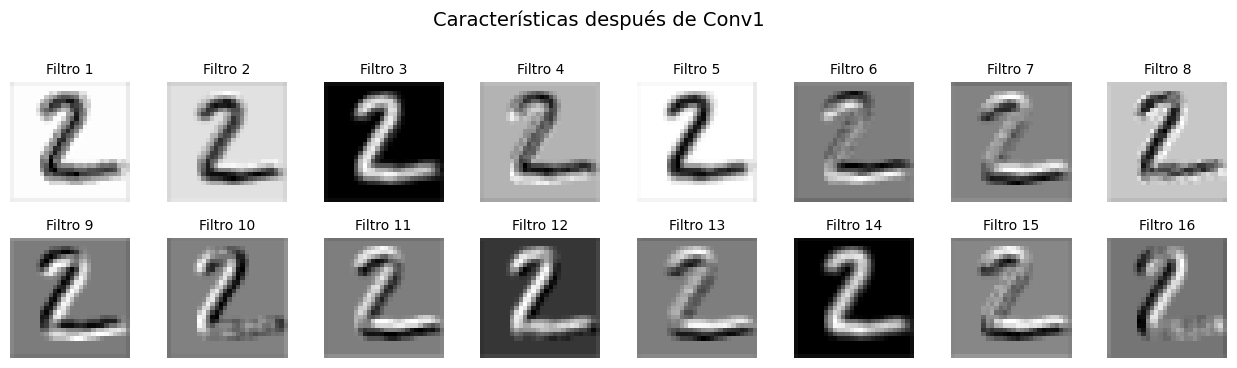

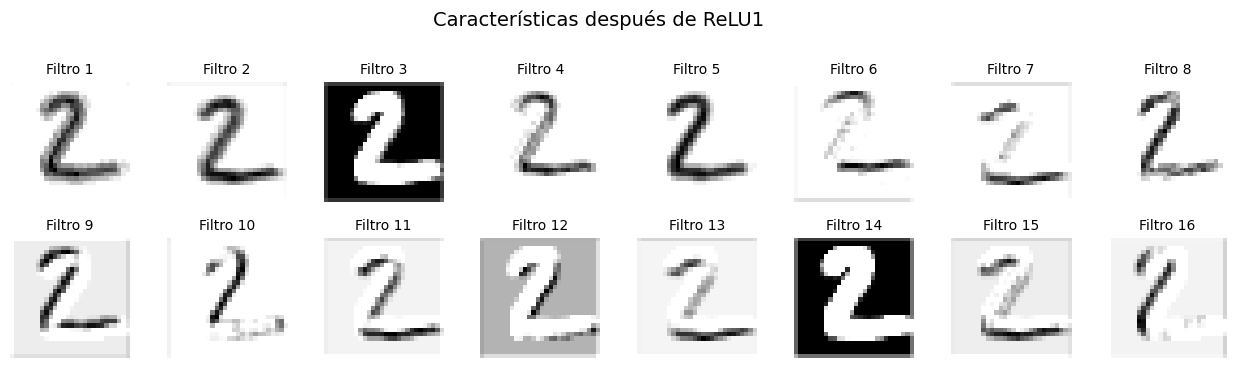

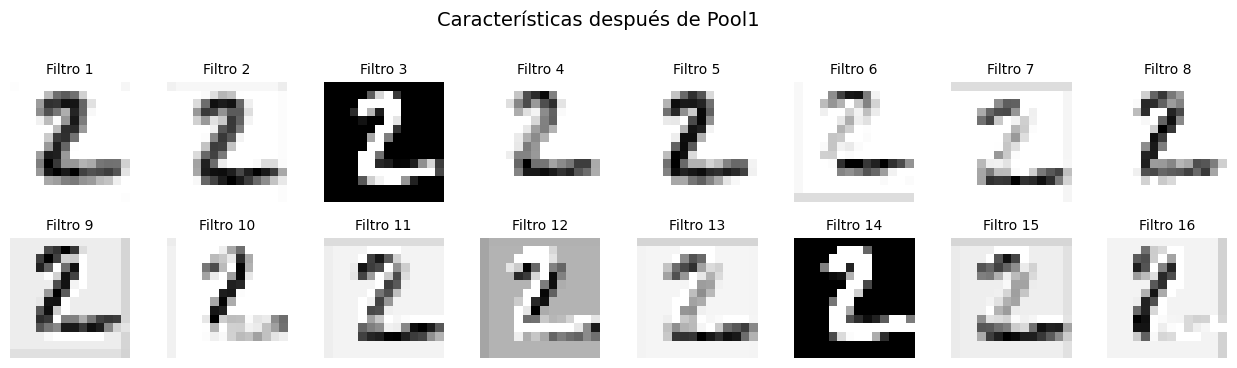

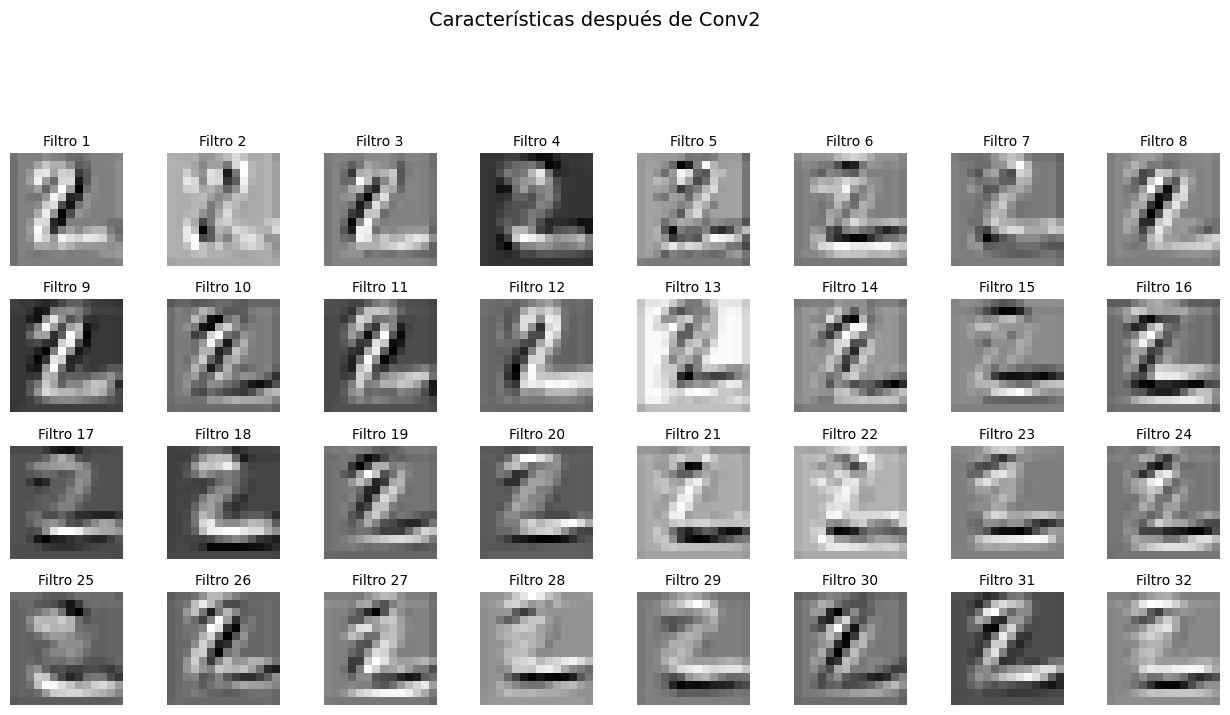

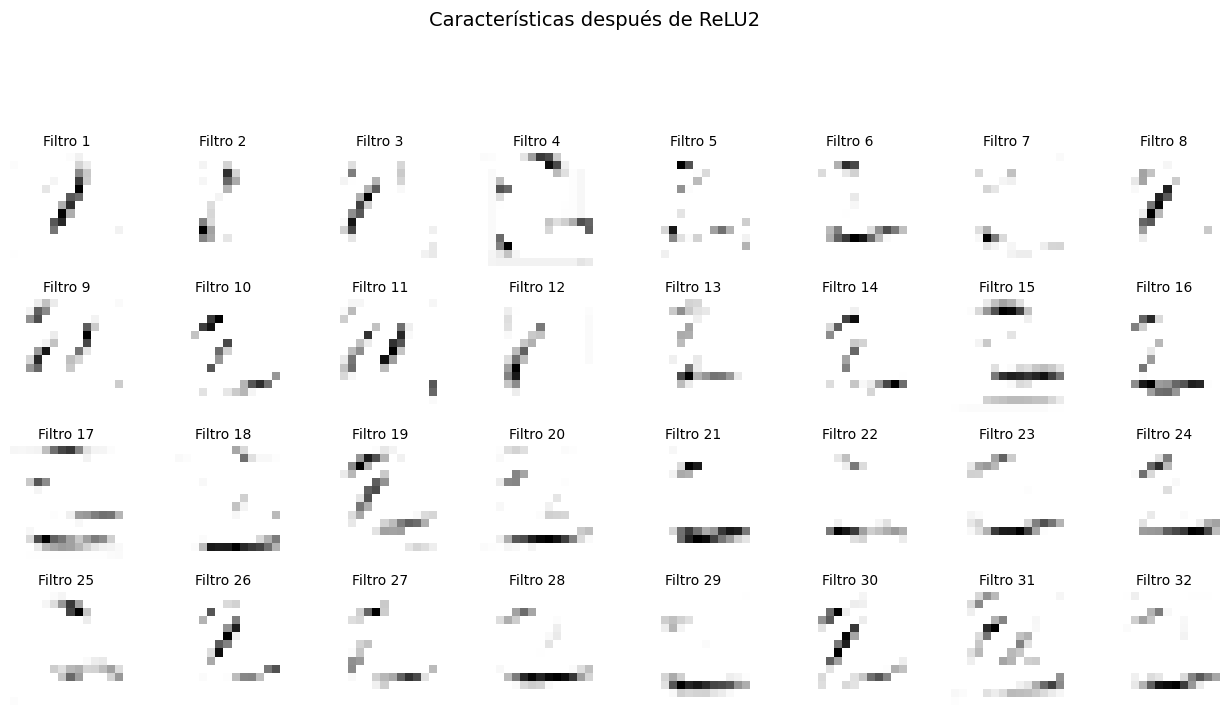

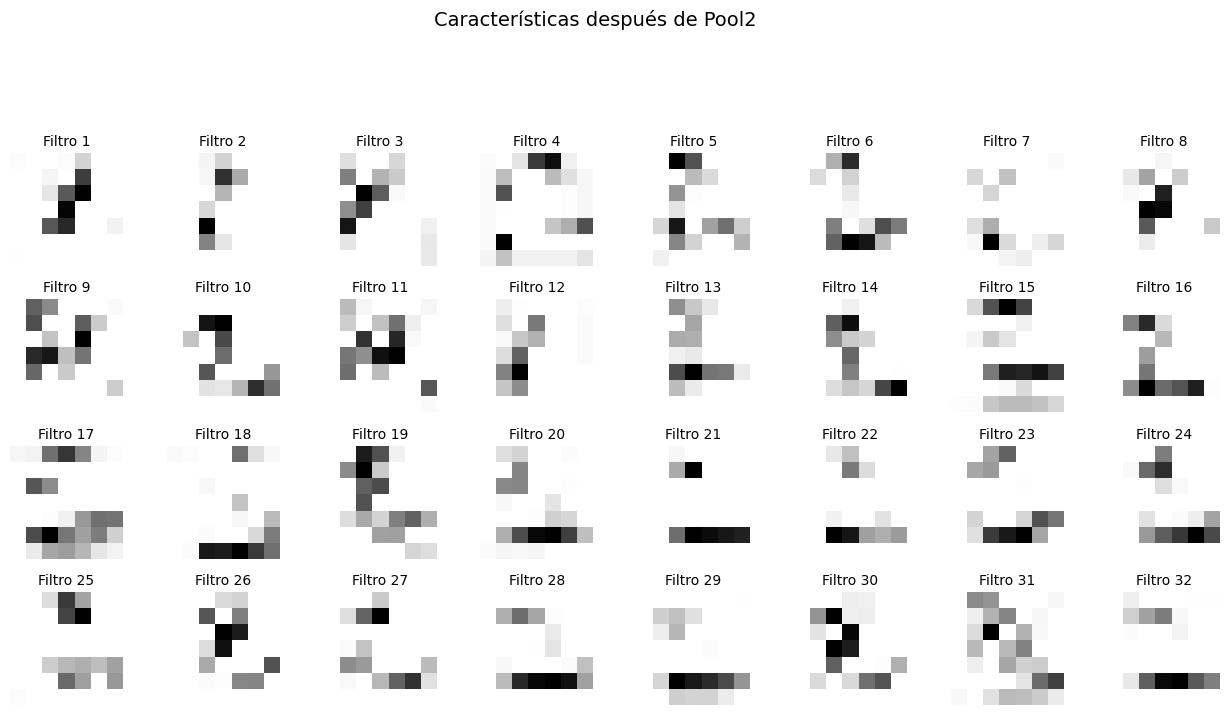

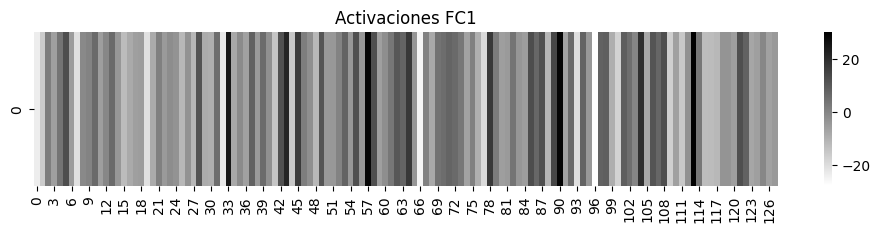

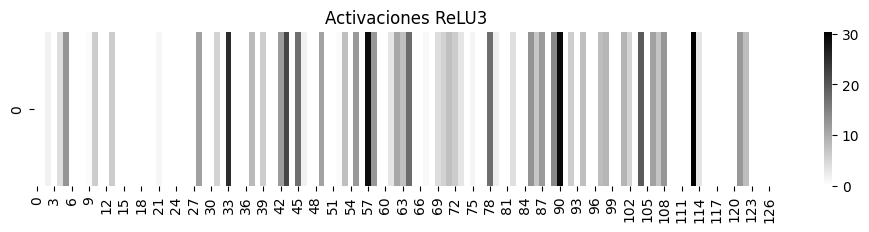

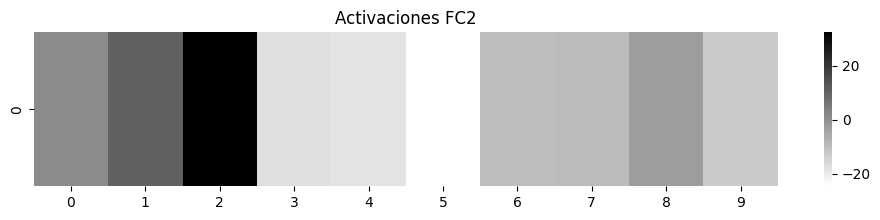

In [16]:
__file__ = os.path.abspath("ejercicio_2_pytorch.ipynb")
current_dir = os.path.dirname(__file__)
img_dir = os.path.join(current_dir, "pytorch-mnist-features")

# Crear carpeta si no existe
os.makedirs(img_dir, exist_ok=True)

print(img_dir)
def visualizar_caracteristicas(modelo, imagen_tensor):
    modelo.eval()
    imagen_tensor = imagen_tensor.to(cfg.device)

    with torch.no_grad():
        features = modelo.conv1(imagen_tensor.unsqueeze(0))
        plot_caracteristicas(features, title="Características después de Conv1")
        features = modelo.relu1(features)
        plot_caracteristicas(features, title="Características después de ReLU1")
        features = modelo.pool1(features)
        plot_caracteristicas(features, title="Características después de Pool1")
        features = modelo.conv2(features)
        plot_caracteristicas(features, title="Características después de Conv2")
        features = modelo.relu2(features)
        plot_caracteristicas(features, title="Características después de ReLU2")
        features = modelo.pool2(features)
        plot_caracteristicas(features, title="Características después de Pool2")
        # Flatten -> FC1 -> ReLU3
        flattened = features.view(features.size(0), -1)
        features = modelo.fc1(flattened)
        plot_fc_features(features, "Activaciones FC1")

        features = modelo.relu3(features)
        plot_fc_features(features, "Activaciones ReLU3")

        features = modelo.fc2(features)
        plot_fc_features(features, "Activaciones FC2")

def plot_caracteristicas(
    features, title
):
    features = features.squeeze(0)  # [canales, H, W]
    num_canales = features.shape[0]

    # Crear subplots
    n_cols = 8
    n_rows = (num_canales + n_cols - 1) // n_cols  # ceil division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))
    
    axes = axes.flatten()  # para iterar fácilmente
    for i in range(num_canales):
        ax = axes[i]
        ax.imshow(features[i].cpu().numpy(), cmap='binary')
        ax.axis('off')
        ax.set_title(f"Filtro {i+1}", fontsize=10)

    # Ajuste final de layout
    plt.subplots_adjust(top=0.8, hspace=0.3, wspace=0.1)
    fig.suptitle(title, fontsize=14)
    filename = title.lower().strip().replace(" ", "_") + ".png"
    filepath = os.path.join(img_dir, filename)
    plt.savefig(filepath, dpi=300)
    plt.show()

def plot_fc_features(features, title):
    features = features.squeeze(0).cpu().numpy()  # [num_neuronas]
    plt.figure(figsize=(12, 2))
    sns.heatmap(features[np.newaxis, :], cmap='binary', cbar=True)
    plt.title(title)
    filename = title.lower().strip().replace(" ", "_") + ".png"
    filepath = os.path.join(img_dir, filename)
    plt.savefig(filepath, dpi=300)
    plt.show()
    
# Visualización de características aprendidas por la primera capa convolucional
sample_img, _ = test_ds[1]
visualizar_caracteristicas(model, sample_img)

Definimos el criterio de pérdida (loss function) y el optimizador que utilizaremos para entrenar el modelo. En este caso, utilizamos la función de pérdida de entropía cruzada (CrossEntropyLoss) y el optimizador Adam.  

CrossEntropyLoss es una función de pérdida comúnmente utilizada para problemas de clasificación, ya que combina la función softmax con la función de pérdida de entropía cruzada.   
Softmax - Si el modelo produce las salidas [2.0, 1.0, 0.1], la función softmax las transformará en probabilidades como [0.7, 0.2, 0.1]. Tienen que sumar 1 y ser mayores que 0.  
Función de pérdida de entropía cruzada - Si la etiqueta verdadera es 0 (primera clase) y el modelo predice [0.7, 0.2, 0.1], la pérdida será baja porque el modelo está haciendo una buena predicción. Si el modelo predice [0.1, 0.2, 0.7], la pérdida será alta porque el modelo está haciendo una mala predicción.  

Adam es un optimizador eficiente que ajusta los pesos del modelo durante el entrenamiento, es muy comúnmente utilizado en redes neuronales debido a su capacidad para manejar grandes cantidades de datos y parámetros.

In [18]:
# Evaluación
print("\nEvaluando modelo...")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(cfg.device)   # <- Mover imágenes al mismo device
        labels = labels.to(cfg.device)   # <- Opcional, si solo necesitas CPU para métricas puedes dejar en CPU
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())  # mover a CPU antes de NumPy
        all_labels.extend(labels.cpu().numpy())
        
acc = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"\nExactitud (Accuracy): {acc * 100:.2f}%")
print("Matriz de Confusión:")
print(cm)



Evaluando modelo...

Exactitud (Accuracy): 99.16%
Matriz de Confusión:
[[ 976    0    1    1    0    1    0    0    1    0]
 [   0 1131    1    1    0    0    0    1    1    0]
 [   0    1 1024    0    1    0    0    5    1    0]
 [   1    0    2 1003    0    3    0    0    1    0]
 [   0    0    1    0  977    0    0    0    1    3]
 [   2    1    0    5    0  882    1    1    0    0]
 [   2    2    0    1    1    2  949    0    1    0]
 [   0    3    4    1    0    0    0 1016    1    3]
 [   3    0    2    1    0    1    1    1  963    2]
 [   0    1    0    3    4    2    0    3    1  995]]
